Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

## Reading in global data

## Running pipeline (loading data, run DMD, recover modes)

In [10]:
# defining test parameters

# Pair and base-set records share one DMD configuration.
non_background_setup = {
    "nmax": 9,
    "svd_rank": 0.999,
    "dmd_settings": {
        "dmd_type": "exact",
        "hankel_flag": True,
        "embedding_d": 3,
        "weight_flag": True,
    },
}

# This is independent so background tests can use different degree,
# rank, or Hankel settings without changing pair/base-set tests.
# The initial values preserve the previous shared configuration.
background_setup = {
    "nmax": 9,
    "svd_rank": 0.999,
    "dmd_settings": {
        "dmd_type": "exact",
        "hankel_flag": True,
        "embedding_d": 6,
        "weight_flag": True,
    },
}

# defining same base set
# defining modes used
base_set_mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
base_set_mode_numbers = [str(mode_number) for mode_number in base_set_mode_numbers]

n_ensemble = 50

mode_colours = {
    mode_num: tol_muted[i]
    for i, mode_num in enumerate(base_set_mode_numbers)
}



In [ ]:
# code to make heatmap - add into heatmap plotter at some point
candidate_mode_numbers = ['62', '6', '48', '45', '32'] # full = ["1", "32", "48"]

guest_type_list = ["disparate", "closest"]
guest_perturb_list = [-50, -40,  -30, -20, -15, -10, -5, 5, 10, 15, 20, 30, 40, 50]
#guest_perturb_list = [-15, -10, -5, 5, 10, 15]
background_type_list = ["pair", "base_set", "background"]

targeted_test_results_total = {}
candidate_true_periods = {}


In [12]:
from unittest.mock import patch
from pydmd.snapshots import Snapshots

# Run each record context with its selected DMD configuration.
for background_type in tqdm(background_type_list, desc="backgrounds"):

    if background_type == "background":
        case_setup = background_setup
    else:
        case_setup = non_background_setup

    case_nmax = case_setup["nmax"]
    case_svd_rank = case_setup["svd_rank"]
    case_dmd_settings = case_setup["dmd_settings"].copy()

    targeted_test_results = {}

    for cand_mode_num in tqdm(candidate_mode_numbers, desc="mode numbers"):

        targeted_test_results[cand_mode_num] = {}

        for guest_type in guest_type_list:

            targeted_test_results[cand_mode_num][guest_type] = {}

            for perturbation in guest_perturb_list:

                targeted_test_results[cand_mode_num][guest_type][perturbation] = {}

                guest_number = f"g{cand_mode_num}_{guest_type}_T{perturbation}"

                if background_type == "base_set" or background_type == "background":
                    mode_numbers = base_set_mode_numbers.copy()
                    mode_numbers.append(guest_number)
                elif background_type == "pair":
                    mode_numbers = [cand_mode_num, guest_number]

                # uncertainty ensemble toggle
                if background_type == "base_set" or background_type == "pair":
                    record_for_ensemble = "resolved"
                else:
                    record_for_ensemble = "background"

                ensemble_settings = {
                    "ensemble_flag":True,
                    "n_ensemble":n_ensemble,
                    "record_for_ensemble":record_for_ensemble
                }

                # getting full (nmax=15) unperturbed records and synthetic suite info
                record_dict, syn_suite_info = Record_Dict_Construct(
                    mode_numbers=mode_numbers, nmax=case_nmax,
                )
                candidate_true_periods[cand_mode_num] = float(
                    syn_suite_info[cand_mode_num]["true_period"]
                )
                

                # getting output of dmd for a run with a specific nmax, svd rank
                # PyDMD's condition-number calculation is diagnostic only
                # and performs an additional SVD. Disable it only for this
                # guest-targeted call; patch restores it on context exit.
                with patch.object(
                    Snapshots,
                    "_check_condition_number",
                    staticmethod(lambda X: None),
                ):
                    results_dict = Pipeline_Run(
                        record_dict, syn_suite_info, case_dmd_settings,
                        nmax=case_nmax, svd_rank=case_svd_rank,
                        ensemble_settings=ensemble_settings,
                    )



                if ensemble_settings["ensemble_flag"]:
                    # check chosen ensemble results
                    ensemble_results = results_dict["ensemble"]


                    num_successful_separations = 0
                    for ensemble_i_idx in ensemble_results:
                        ensemble_i_results = ensemble_results[ensemble_i_idx]
                        if not isinstance(ensemble_i_results, dict):
                            continue

                        candidate_results = ensemble_i_results.get(cand_mode_num, False)
                        guest_results = ensemble_i_results.get(guest_number, False)

                        # Both modes must be independently retrieved.
                        # False excludes an unmatched mode; integer 0 excludes
                        # a guest merged with its candidate.
                        if (
                            isinstance(candidate_results, dict)
                            and isinstance(guest_results, dict)
                        ):
                            num_successful_separations += 1


                    targeted_test_results[cand_mode_num][guest_type][perturbation] = num_successful_separations
                else:
                    results = results_dict[record_for_ensemble]
                    candidate_results = results[cand_mode_num]
                    guest_results = results[guest_number]

                    if candidate_results and type(guest_results) != int:
                        targeted_test_results[cand_mode_num][guest_type][perturbation] = \
                            results[cand_mode_num]["match_similarity"]

    targeted_test_results_total[background_type] = targeted_test_results



backgrounds:   0%|          | 0/3 [00:00<?, ?it/s]

/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1428: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
backgrounds: 100%|██████████| 3/3 [26:38<00:00, 532.87s/it]


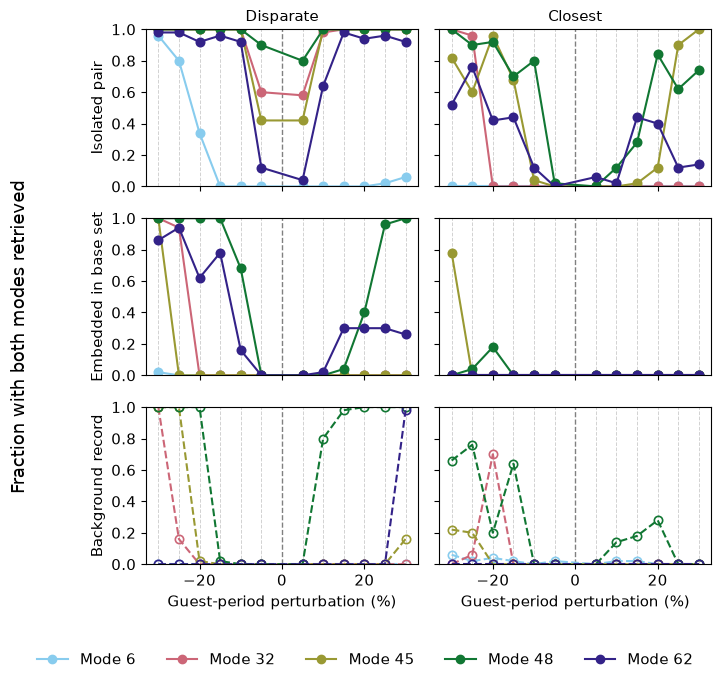

In [13]:
# Mode order and corresponding colours.
mode_colours = {
    mode_num: tol_muted[i]
    for i, mode_num in enumerate(base_set_mode_numbers)
}

# Draw longest-period targets first so shorter-period markers remain
# visible where candidate curves overlap.
candidate_plot_order = sorted(
    candidate_mode_numbers,
    key=lambda mode_num: candidate_true_periods[mode_num],
    reverse=True,
)

targeted_period_figure, targeted_period_axes = Plot_Targeted_Period_Recovery(
    targeted_test_results_total, candidate_plot_order,
    guest_type_list, guest_perturb_list, n_ensemble, mode_colours,
    figure_width=text_width, background_type_order=background_type_list,
)
plt.show()

## Base-set period error across SVD rank truncations

The resolved base set is tested without and with the non-wave background. Each case retains its configured degree, DMD type, weighting, and Hankel embedding. Period-error summaries are conditional on a successful mode match in the ensemble.

In [8]:
rank_truncation_values = [0.9, 0.99, 0.999, 0.9999, -1]
rank_truncation_values = [0.9982, 0.9984, 0.9986, 0.9988, 0.9990, 0.9992, 0.9994, 0.9996, 0.9998]

# The two cases use the independently configured setups defined above.
rank_sweep_cases = {
    "resolved": {
        "title": "No background",
        "record_key": "resolved",
        "setup": non_background_setup,
    },
    "background": {
        "title": "Background",
        "record_key": "background",
        "setup": background_setup,
    },
}

rank_truncation_results = {}

for case_key, case in tqdm(
    rank_sweep_cases.items(), desc="base-set background cases"
):
    case_setup = case["setup"]
    case_nmax = case_setup["nmax"]
    case_dmd_settings = case_setup["dmd_settings"].copy()

    # Construct only the resolved base-set waves; no guest wave is added.
    record_dict, syn_suite_info = Record_Dict_Construct(
        mode_numbers=base_set_mode_numbers, nmax=case_nmax,
    )

    case_results = {
        "effective_rank_median": [],
        "modes": {
            mode_num: {"median": [], "p05": [], "p95": []}
            for mode_num in base_set_mode_numbers
        },
    }

    for svd_rank in tqdm(
        rank_truncation_values, desc=case["title"], leave=False
    ):
        results_dict = Pipeline_Run(
            record_dict,
            syn_suite_info,
            case_dmd_settings,
            nmax=case_nmax,
            svd_rank=svd_rank,
            ensemble_settings={
                "ensemble_flag": True,
                "n_ensemble": n_ensemble,
                "record_for_ensemble": case["record_key"],
            },
        )
        results_dict = Ensemble_To_Median(results_dict, syn_suite_info)

        case_results["effective_rank_median"].append(
            results_dict["median"]["effective_rank"]["value"]
        )

        for mode_num in base_set_mode_numbers:
            mode_results = results_dict["median"][mode_num]
            if mode_results["runs_with_mode_match"] > 0:
                period_errors = mode_results["match_period_errors"]
                case_results["modes"][mode_num]["median"].append(
                    period_errors["value"]
                )
                case_results["modes"][mode_num]["p05"].append(
                    period_errors["p05"]
                )
                case_results["modes"][mode_num]["p95"].append(
                    period_errors["p95"]
                )
            else:
                for percentile in ("median", "p05", "p95"):
                    case_results["modes"][mode_num][percentile].append(
                        np.nan
                    )

    rank_truncation_results[case_key] = case_results

base-set background cases:   0%|          | 0/2 [00:00<?, ?it/s]

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.6163925781279034e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1424267.0346454089. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 234069.465892784. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project

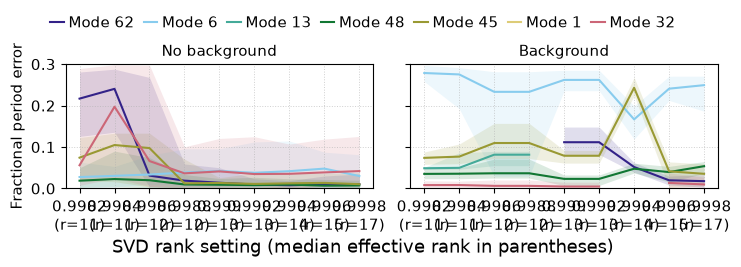

In [9]:
rank_x = np.arange(len(rank_truncation_values))
rank_error_figure, rank_error_axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(text_width, 0.35 * text_width),
    sharex=True,
    sharey=True,
)

legend_handles = []
for axis, (case_key, case) in zip(
    rank_error_axes, rank_sweep_cases.items()
):
    case_results = rank_truncation_results[case_key]

    for mode_num in base_set_mode_numbers:
        mode_results = case_results["modes"][mode_num]
        median = np.asarray(mode_results["median"], dtype=float)
        p05 = np.asarray(mode_results["p05"], dtype=float)
        p95 = np.asarray(mode_results["p95"], dtype=float)
        mode_colour = mode_colours[mode_num]

        line, = axis.plot(
            rank_x,
            median,
            color=mode_colour,
            linewidth=1.5,
            label=f"Mode {mode_num}",
            zorder=2,
        )
        axis.fill_between(
            rank_x,
            p05,
            p95,
            color=mode_colour,
            alpha=0.15,
            linewidth=0,
            zorder=1,
        )
        if case_key == "resolved":
            legend_handles.append(line)

    effective_rank_labels = []
    for svd_rank, effective_rank in zip(
        rank_truncation_values,
        case_results["effective_rank_median"],
    ):
        rank_setting_label = f"{svd_rank:g}"
        if np.isfinite(effective_rank):
            if np.isclose(effective_rank, np.rint(effective_rank)):
                effective_rank_label = f"{int(np.rint(effective_rank))}"
            else:
                # An even-sized ensemble can have a half-integer median.
                effective_rank_label = f"{effective_rank:.1f}"
        else:
            effective_rank_label = "--"
        effective_rank_labels.append(
            f"{rank_setting_label}\n(r={effective_rank_label})"
        )

    axis.set_title(case["title"])
    axis.set_xticks(rank_x)
    axis.set_xticklabels(effective_rank_labels)
    axis.set_xlim(rank_x[0] - 0.4, rank_x[-1] + 0.4)
    axis.set_ylim(0, 0.30)
    axis.set_yticks(np.arange(0, 0.31, 0.1))
    axis.grid(
        True,
        which="major",
        linestyle=":",
        linewidth=0.7,
        alpha=0.6,
    )

rank_error_axes[0].set_ylabel("Fractional period error")
rank_error_figure.supxlabel(
    "SVD rank setting (median effective rank in parentheses)", y=0.02
)
rank_error_figure.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=len(base_set_mode_numbers),
    frameon=False,
    handlelength=0.9,
    handletextpad=0.3,
    columnspacing=0.6,
    borderaxespad=0,
)
rank_error_figure.subplots_adjust(
    left=0.09, right=0.99, bottom=0.29, top=0.78, wspace=0.12
)
plt.show()